In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"farizcharamadhani","key":"58abb01d9532a67a1805c5c336b9c846"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d chanchal24/breast-cancer-dataset
!unzip breast-cancer-dataset.zip

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open breast-cancer-dataset.zip, breast-cancer-dataset.zip.zip or breast-cancer-dataset.zip.ZIP.


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d chanchal24/breast-cancer-dataset
!unzip breast-cancer-dataset.zip

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open breast-cancer-dataset.zip, breast-cancer-dataset.zip.zip or breast-cancer-dataset.zip.ZIP.


In [ ]:
!kaggle datasets download -d chanchal24/breast-cancer-dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving breast-cancer.csv to breast-cancer.csv


In [ ]:
df = pd.read_csv('/content/data.csv')
print(df.head())

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


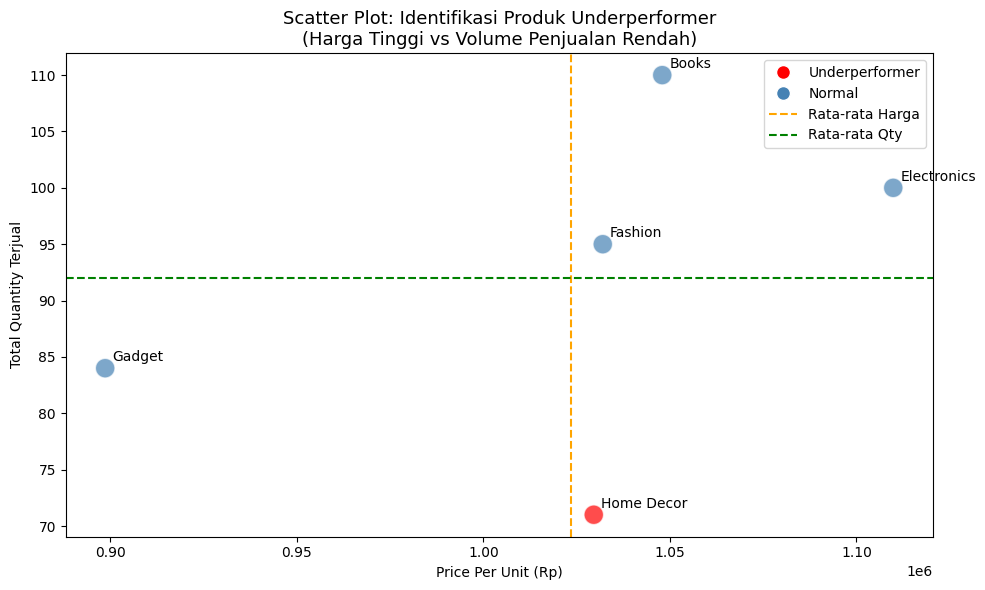


Rata-rata Harga: Rp 1,023,599
Rata-rata Quantity: 92.0

Produk Underperformer:
  Product_Category  Price_Per_Unit  Quantity
4       Home Decor    1.029583e+06        71


In [ ]:
# Tugas 1

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.read_csv('data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Total_Sales'] = df['Total_Sales'].fillna(df['Quantity'] * df['Price_Per_Unit'])

produk = df.groupby('Product_Category').agg(
    Price_Per_Unit=('Price_Per_Unit', 'mean'),
    Quantity=('Quantity', 'sum')
).reset_index()

rata_rata_harga = produk['Price_Per_Unit'].mean()
rata_rata_qty = produk['Quantity'].mean()

produk['Status'] = 'Normal'
produk.loc[
    (produk['Price_Per_Unit'] > rata_rata_harga) &
    (produk['Quantity'] < rata_rata_qty),
    'Status'
] = 'Underperformer'

warna = produk['Status'].map({'Underperformer': 'red', 'Normal': 'steelblue'})

plt.figure(figsize=(10, 6))
plt.scatter(
    produk['Price_Per_Unit'],
    produk['Quantity'],
    c=warna,
    alpha=0.7,
    s=200,
    edgecolors='white'
)

plt.axvline(x=rata_rata_harga, color='orange', linestyle='--', label=f'Rata-rata Harga: Rp {rata_rata_harga:,.0f}')
plt.axhline(y=rata_rata_qty, color='green', linestyle='--', label=f'Rata-rata Qty: {rata_rata_qty:.1f}')

for _, row in produk.iterrows():
    plt.annotate(
        row['Product_Category'],
        (row['Price_Per_Unit'], row['Quantity']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=10
    )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Underperformer'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Normal'),
    Line2D([0], [0], color='orange', linestyle='--', label='Rata-rata Harga'),
    Line2D([0], [0], color='green', linestyle='--', label='Rata-rata Qty'),
]
plt.legend(handles=legend_elements)

plt.title('Scatter Plot: Identifikasi Produk Underperformer\n(Harga Tinggi vs Volume Penjualan Rendah)', fontsize=13)
plt.xlabel('Price Per Unit (Rp)')
plt.ylabel('Total Quantity Terjual')
plt.tight_layout()
plt.savefig('tugas1_underperformer.png')
plt.show()

print(f'\nRata-rata Harga: Rp {rata_rata_harga:,.0f}')
print(f'Rata-rata Quantity: {rata_rata_qty:.1f}')
print('\nProduk Underperformer:')
print(produk[produk['Status'] == 'Underperformer'][['Product_Category', 'Price_Per_Unit', 'Quantity']])

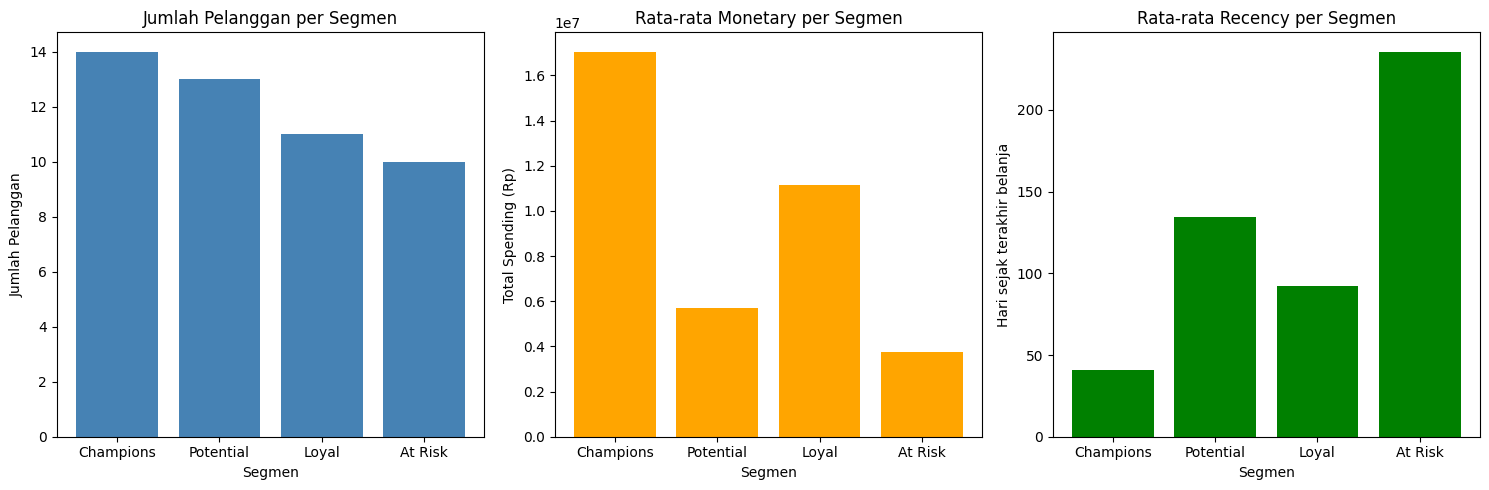


=== Pelanggan Layak Dapat Voucher Loyalitas ===
    CustomerID  Recency  Frequency    Monetary RFM_Score  RFM_Total    Segment
7         5008       15          6  22350000.0       555         15  Champions
14        5015       21          6  27741000.0       555         15  Champions
43        5044       18          7  20631000.0       555         15  Champions
34        5035       53          6  22066000.0       455         14  Champions
13        5014       54          6  20797000.0       455         14  Champions
41        5042        1          4  18754000.0       545         14  Champions
20        5021        2          4  10624000.0       544         13  Champions
8         5009       12          5   9334000.0       553         13  Champions
45        5047       43          5  10351000.0       454         13  Champions
25        5026       36          5  15835000.0       454         13  Champions
38        5039      124          5  11879000.0       354         12  Champions
24 

In [ ]:
# Tugas 2

import datetime as dt

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID', 'count'),
    Monetary=('Total_Sales', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segmentasi(score):
    if score >= 12:
        return 'Champions'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Total'].apply(segmentasi)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(rfm['Segment'].value_counts().index, rfm['Segment'].value_counts().values, color='steelblue')
axes[0].set_title('Jumlah Pelanggan per Segmen')
axes[0].set_xlabel('Segmen')
axes[0].set_ylabel('Jumlah Pelanggan')

axes[1].bar(rfm['Segment'].value_counts().index,
            rfm.groupby('Segment')['Monetary'].mean().reindex(rfm['Segment'].value_counts().index),
            color='orange')
axes[1].set_title('Rata-rata Monetary per Segmen')
axes[1].set_xlabel('Segmen')
axes[1].set_ylabel('Total Spending (Rp)')

axes[2].bar(rfm['Segment'].value_counts().index,
            rfm.groupby('Segment')['Recency'].mean().reindex(rfm['Segment'].value_counts().index),
            color='green')
axes[2].set_title('Rata-rata Recency per Segmen')
axes[2].set_xlabel('Segmen')
axes[2].set_ylabel('Hari sejak terakhir belanja')

plt.tight_layout()
plt.savefig('tugas2_rfm.png')
plt.show()

print('\n=== Pelanggan Layak Dapat Voucher Loyalitas ===')
voucher = rfm[rfm['Segment'].isin(['Champions', 'Loyal'])][['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']]
voucher = rfm[rfm['Segment'].isin(['Champions', 'Loyal'])][['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'RFM_Total', 'Segment']]
print(voucher.sort_values('RFM_Total', ascending=False))
print(f'\nTotal pelanggan layak voucher: {len(voucher)} orang')

print('\n=== Tabel RFM Lengkap ===')
print(rfm.sort_values('RFM_Total', ascending=False).head(10))

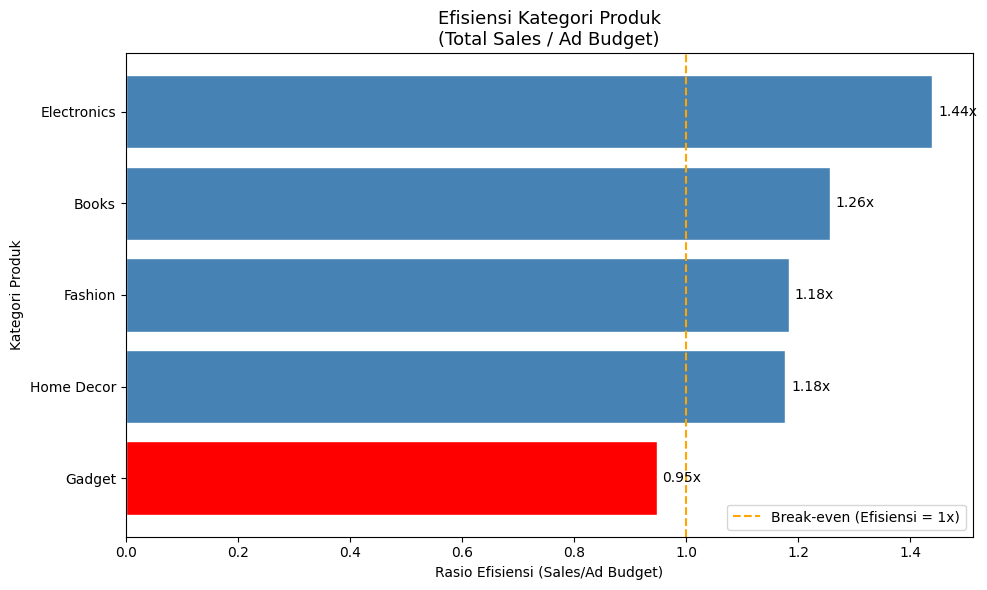


=== Tabel Efisiensi Kategori ===
Product_Category  Total_Sales  Ad_Budget  Efisiensi
          Gadget   72506000.0 76539000.0   0.947308
      Home Decor   76292000.0 64808000.0   1.177200
         Fashion   97466000.0 82317000.0   1.184032
           Books  112934000.0 89914000.0   1.256022
     Electronics  114095000.0 79264000.0   1.439430


In [ ]:
# Tugas 3

kategori = df.groupby('Product_Category').agg(
    Total_Sales=('Total_Sales', 'sum'),
    Ad_Budget=('Ad_Budget', 'sum')
).reset_index()

kategori['Efisiensi'] = kategori['Total_Sales'] / kategori['Ad_Budget']
kategori = kategori.sort_values('Efisiensi', ascending=True)

warna = ['red' if e < 1 else 'steelblue' for e in kategori['Efisiensi']]

plt.figure(figsize=(10, 6))
bars = plt.barh(kategori['Product_Category'], kategori['Efisiensi'], color=warna, edgecolor='white')

for bar, val in zip(bars, kategori['Efisiensi']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}x', va='center', fontsize=10)

plt.axvline(x=1, color='orange', linestyle='--', label='Break-even (Efisiensi = 1x)')
plt.title('Efisiensi Kategori Produk\n(Total Sales / Ad Budget)', fontsize=13)
plt.xlabel('Rasio Efisiensi (Sales/Ad Budget)')
plt.ylabel('Kategori Produk')
plt.legend()
plt.tight_layout()
plt.savefig('tugas3_efisiensi.png')
plt.show()

print('\n=== Tabel Efisiensi Kategori ===')
print(kategori[['Product_Category', 'Total_Sales', 'Ad_Budget', 'Efisiensi']].to_string(index=False))

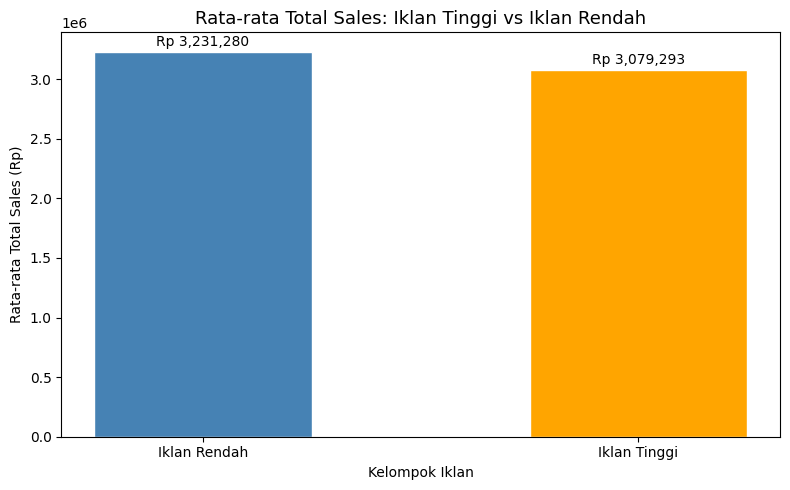

Median Ad Budget: Rp 2,722,500
Rata-rata Sales Iklan Rendah: Rp 3,231,280
Rata-rata Sales Iklan Tinggi: Rp 3,079,293

T-Statistic: -0.3743
P-Value: 0.7087

Kesimpulan: Perbedaan TIDAK SIGNIFIKAN ✗
Iklan tinggi tidak terbukti meningkatkan penjualan secara signifikan.


In [ ]:
# Tugas 4

from scipy import stats

median_ad = df['Ad_Budget'].median()

iklan_tinggi = df[df['Ad_Budget'] > median_ad]['Total_Sales']
iklan_rendah = df[df['Ad_Budget'] <= median_ad]['Total_Sales']

t_stat, p_value = stats.ttest_ind(iklan_tinggi, iklan_rendah)

plt.figure(figsize=(8, 5))
plt.bar(['Iklan Rendah', 'Iklan Tinggi'],
        [iklan_rendah.mean(), iklan_tinggi.mean()],
        color=['steelblue', 'orange'],
        edgecolor='white',
        width=0.5)

plt.title('Rata-rata Total Sales: Iklan Tinggi vs Iklan Rendah', fontsize=13)
plt.xlabel('Kelompok Iklan')
plt.ylabel('Rata-rata Total Sales (Rp)')

for i, val in enumerate([iklan_rendah.mean(), iklan_tinggi.mean()]):
    plt.text(i, val + 50000, f'Rp {val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('tugas4_hipotesis.png')
plt.show()

print(f'Median Ad Budget: Rp {median_ad:,.0f}')
print(f'Rata-rata Sales Iklan Rendah: Rp {iklan_rendah.mean():,.0f}')
print(f'Rata-rata Sales Iklan Tinggi: Rp {iklan_tinggi.mean():,.0f}')
print(f'\nT-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

if p_value < 0.05:
    print('\nKesimpulan: Perbedaan SIGNIFIKAN ✓')
    print('Iklan tinggi terbukti meningkatkan penjualan secara signifikan.')
else:
    print('\nKesimpulan: Perbedaan TIDAK SIGNIFIKAN ✗')
    print('Iklan tinggi tidak terbukti meningkatkan penjualan secara signifikan.')

In [ ]:
# Tugas 5

import datetime as dt

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5001            213          4   8562000.0       1       4       3       143
5002             77          4   8983000.0       3       4       3       343
5003            118          3   9433000.0       3       2       3       323
5004            196          3  20268000.0       2       3       5       235
5005             23          2   9105000.0       5       2       3       523
5006            174          1   1550000.0       2       1       1       211
5007             35          4   7520000.0       4       4       3       443
5008             15          6  22350000.0       5       5       5       555
5009             12          5   9334000.0       5       5       3       553
5010            136          1   5630000.0       2       1       2       212


In [ ]:
# Tugas 6

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Ad_Budget']]
y = df['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")

Koefisien Iklan: 0.08953632188546166
Akurasi Model (R2 Score): -0.0727826335616284
